<a href="https://colab.research.google.com/github/mahnooriqbal212/fitness-class-attendance-eda/blob/main/fitness_class_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Fitness Dataset from Kaggle:
https://www.kaggle.com/datasets/ddosad/datacamps-data-science-associate-certification?resource=download

# Step 2: Initial Data Exploration & Inspection

In [18]:
df = pd.read_csv("fitness_class_2212.csv")  # Requirement 1
print(df.shape)
print(df.head(10))
df.info()
print("\n",df.describe())
print("\nCOLUMNS' DATATYPES: ",df.dtypes)

(1500, 8)
   booking_id  months_as_member  weight days_before day_of_week time  \
0           1                17   79.56           8         Wed   PM   
1           2                10   79.01           2         Mon   AM   
2           3                16   74.53          14         Sun   AM   
3           4                 5   86.12          10         Fri   AM   
4           5                15   69.29           8         Thu   AM   
5           6                 7   93.33           2         Mon   AM   
6           7                11   88.59           6   Wednesday   PM   
7           8                 9   89.52          10         Fri   AM   
8           9                23   71.12          10        Fri.   AM   
9          10                 7   81.25          10         Fri   AM   

   category  attended  
0  Strength         0  
1      HIIT         0  
2  Strength         0  
3   Cycling         0  
4      HIIT         0  
5   Cycling         0  
6      HIIT         0  
7    

## Columns
### ID Column:

* booking_id: Unique identifier for each booking (sequential integer from 1 to 1500).

### Numeric Columns:

* months_as_member: Discrete numeric count of months.

* weight: Continuous numeric measure (contains 20 missing/null values).

* days_before: Numeric concept (number of days booked in advance), though stored as object/str (likely due to trailing text or spaces needing cleaning).

### Categorical Columns:

* day_of_week: Categorical text (Wed, Mon, Wednesday, Fri., etc.—note inconsistent formatting).

* time: Categorical text with two distinct values (AM, PM).

* category: Categorical text representing the fitness class type (Strength, HIIT, Cycling, etc.).

* attended: Binary target variable (0 or 1), practically categorical (encoded as numeric integer).

## What is this Dataset about?
This dataset contains information on 1,500 fitness class bookings, tracking member attributes like membership duration, weight, booking advance time, scheduled day/time, and class category. The primary objective is to analyze member attendance behavior and optimize class booking patterns.
#### By the end of this analysis, we aim to answer:
1. What factors (such as membership length or booking lead time) best predict whether a member will attend a class?
2. Which class categories and time slots (AM vs. PM) have the highest attendance and demand?
3. Does booking significantly in advance (`days_before`) correlate with higher or lower attendance rates?

# Step 3: Clean, Transform & Explore
# Task 1: Handle missing values

In [19]:
df_copy = df.copy() # Requirement 2
print("CHECK FOR MISSING VALUES")
print(df_copy.isna().sum()) # check missing values

# fill missing values by median in groups by "category" as there are 20 missing values in weight (dropping them loses significant data entries)
df_copy['weight'] = df_copy['weight'].fillna(df_copy.groupby('category')['weight'].transform('median'))
print("\nCHECK IF NO MISSING VALUES :\n ")
print(df_copy.isna().sum()) # verify no missing values

CHECK FOR MISSING VALUES
booking_id           0
months_as_member     0
weight              20
days_before          0
day_of_week          0
time                 0
category             0
attended             0
dtype: int64

CHECK IF NO MISSING VALUES :
 
booking_id          0
months_as_member    0
weight              0
days_before         0
day_of_week         0
time                0
category            0
attended            0
dtype: int64


# Task 2: Fix/transform at least one column
The column 'day_of_week' has  nconsistent entries like 'Wed', 'Wednesday', and 'Fri.'
Standardizing all days to 3-letter abbreviations

In [20]:
day_map = {
    'Wednesday': 'Wed', 'Wed': 'Wed',
    'Monday': 'Mon', 'Mon': 'Mon',
    'Friday': 'Fri', 'Fri': 'Fri', 'Fri.': 'Fri',
    'Thursday': 'Thu', 'Thu': 'Thu',
    'Tuesday': 'Tue', 'Tue': 'Tue',
    'Sunday': 'Sun', 'Sun': 'Sun',
    'Saturday': 'Sat', 'Sat': 'Sat'
}

df_copy['day_of_week'] = df_copy['day_of_week'].str.strip().map(day_map)
print(df_copy.head(20))

    booking_id  months_as_member  weight days_before day_of_week time  \
0            1                17   79.56           8         Wed   PM   
1            2                10   79.01           2         Mon   AM   
2            3                16   74.53          14         Sun   AM   
3            4                 5   86.12          10         Fri   AM   
4            5                15   69.29           8         Thu   AM   
5            6                 7   93.33           2         Mon   AM   
6            7                11   88.59           6         Wed   PM   
7            8                 9   89.52          10         Fri   AM   
8            9                23   71.12          10         Fri   AM   
9           10                 7   81.25          10         Fri   AM   
10          11                13   73.22           4         Tue   AM   
11          12                16   86.86          10         Fri   AM   
12          13                16   71.70          1

# Task 3: Look at distributions

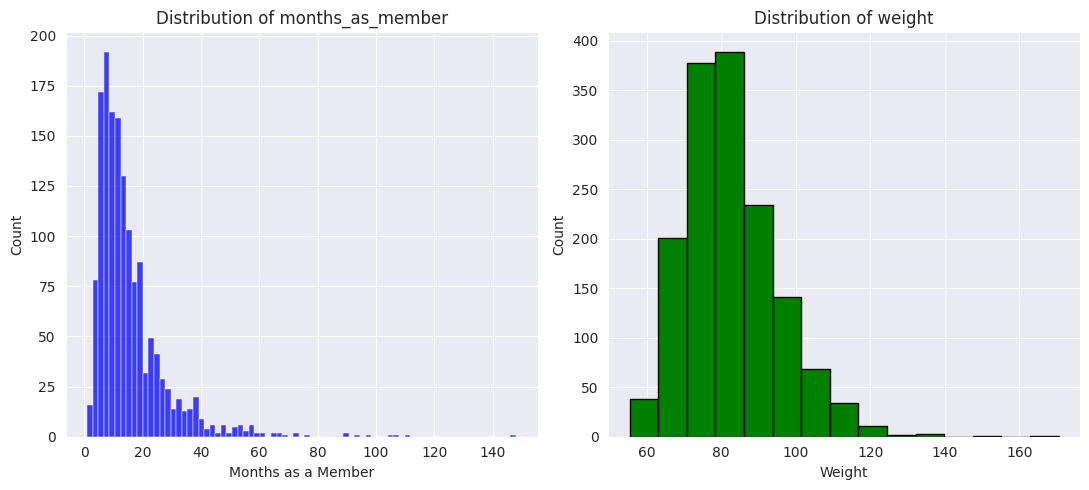

In [21]:
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 1. "months_as_member" Seaborn Histogram
sns.histplot(df_copy['months_as_member'], ax=axes[0], color='blue')
axes[0].set_title('Distribution of months_as_member')
axes[0].set_xlabel('Months as a Member')
axes[0].set_ylabel('Count')

# 2. "weight" Matplotlib Histogram
axes[1].hist(df_copy['weight'], color='green', edgecolor='black', bins=15)  # Requirement 13
axes[1].set_title('Distribution of weight')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### months_as_member (Strongly Right-Skewed)
The majority of members have been enrolled for fewer than 20 months (median = 12), with a long right tail stretching up to 148 months.
### weight (Roughly Normal with Right-Skew / Outliers)
The central mass follows a bell curve centered around 80–83 kg. However, it exhibits a slight right skew.

# Task 4: Find outliers

Outlier Report: months_as_member 

Q1: 8.00 | Q3: 19.00 | IQR: 11.00
Lower Threshold: -8.50
Upper Threshold: 35.50
Total Outliers Found: 103 (6.87%)

     booking_id  months_as_member  weight  attended
54           55                53   61.10         1
92           93                73   66.00         1
98           99                55   62.92         1
121         122                54   73.02         1
124         125                76   58.68         1
138         139                62   57.83         1
140         141                42   59.97         1
143         144               105   66.07         1
150         151                90   58.13         1
155         156                60   68.02         1
Outlier Report: weight 

Q1: 73.56 | Q3: 89.38 | IQR: 15.82
Lower Threshold: 49.83
Upper Threshold: 113.11
Total Outliers Found: 30 (2.00%)

     booking_id  months_as_member  weight  attended
82           83                 6  117.19         0
99          100                 4

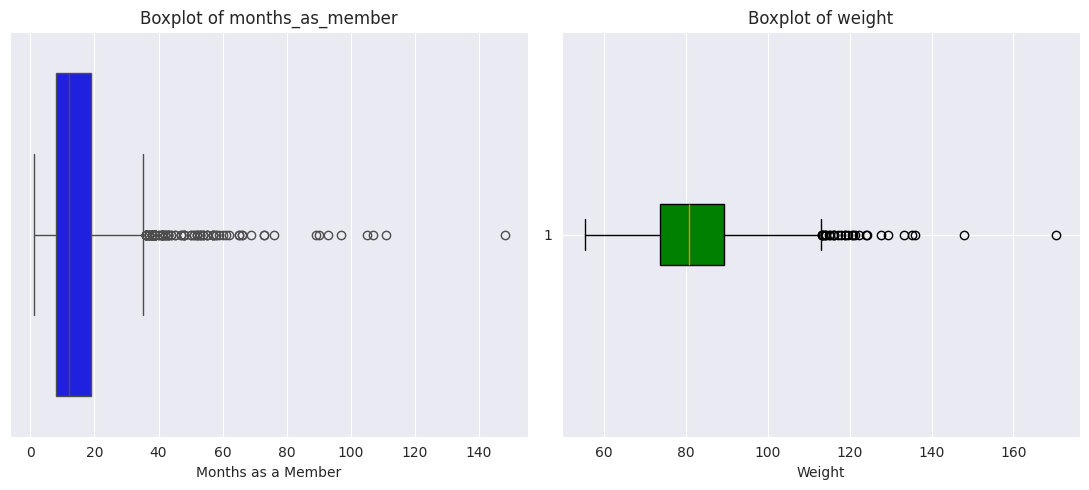

In [22]:
def detect_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)  # Requirement 3
    outlier_rows = df[outlier_mask]

    print(f"Outlier Report: {column} \n")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Lower Threshold: {lower_bound:.2f}")
    print(f"Upper Threshold: {upper_bound:.2f}")
    print(f"Total Outliers Found: {len(outlier_rows)} ({len(outlier_rows) / len(df) * 100:.2f}%)\n")

    return outlier_rows

# Detect outliers for months_as_member
outliers_months = detect_iqr_outliers(df_copy, 'months_as_member')
print(outliers_months[['booking_id', 'months_as_member', 'weight', 'attended']].head(10))

# Detect outliers for weight
outliers_weight = detect_iqr_outliers(df_copy, 'weight')
print(outliers_weight[['booking_id', 'months_as_member', 'weight', 'attended']].head(10))

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Requirement 12: Boxplots - Visualize outliers

# 1. "months_as_member" Seaborn Boxplot
sns.boxplot(x=df_copy['months_as_member'], ax=axes[0], color='blue')
axes[0].set_title('Boxplot of months_as_member')
axes[0].set_xlabel('Months as a Member')

# 2. "weight" Matplotlib Boxplot
axes[1].boxplot(df_copy['weight'], vert=False, patch_artist=True,
               boxprops=dict(facecolor='green', color='black'))
axes[1].set_title('Boxplot of weight')
axes[1].set_xlabel('Weight')

plt.tight_layout()
plt.show()


The above results from boxplot graphs show that there are some outliers both in "weight" and "months_as_member" columns. The exact number of outliers are calculated by the IQR method. There are 103 (6.87%) and 30 (2.00%) outliers in "months_as_member" and "weight" respectively out of 1500 data entries.

# Task 5: Check correlations

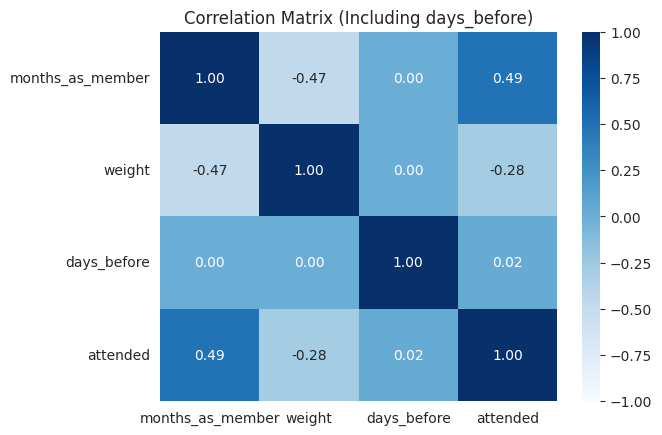

In [23]:
# In column 'days_before' Extract the digits from the string and convert to numeric (int64)
df_copy['days_before'] = df_copy['days_before'].astype(str).str.extract(r'(\d+)').astype(float)

# Requirement 11
corr_matrix = df_copy[['months_as_member', 'weight', 'days_before', 'attended']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Blues", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix (Including days_before)")
plt.show()

## 1. "months_as_member" and "attended" (+0.49) — Strongest Positive Pair
As the number of months a person has been a member increases, their likelihood of attending the event also increases. They move together in the same direction.
## 2. "days_before" and "attended" (+0.02) — Very Weak Positive Pair
Meaning: There is a slight positive relationship, but at 0.02, it is practically zero (meaning how early someone books has almost no linear relationship with attendance).
## Inverse / Negative Correlation
* "months_as_member" and "weight" (-0.47): Longer-standing members tend to have lower weight.
* "weight" and "attended" (-0.28): Higher weight shows a slight negative association with attendance.

# Task 6: Group and compare

In [24]:
# Requirement 9, 10
category_summary = df_copy.groupby('category')['attended'].agg(
    total_bookings='count',
    attendance_rate='mean',
    total_attended='sum'
).reset_index()

print(category_summary)

group_comparison = df_copy.groupby('category')[['months_as_member', 'weight']].agg(['mean', 'median', 'std'])
print(group_comparison)

   category  total_bookings  attendance_rate  total_attended
0         -              13         0.153846               2
1      Aqua              76         0.328947              25
2   Cycling             376         0.292553             110
3      HIIT             667         0.319340             213
4  Strength             233         0.266094              62
5      Yoga             135         0.311111              42
         months_as_member                       weight                   
                     mean median        std       mean  median        std
category                                                                 
-               15.076923   11.0  12.730944  81.256154  77.430  11.207420
Aqua            17.276316   13.0  18.978302  81.387237  80.385  12.417525
Cycling         15.316489   13.0  11.028610  82.919335  81.330  11.723835
HIIT            15.770615   12.0  13.311576  82.646312  80.650  12.973580
Strength        15.244635   12.0  13.317259  81.701330 

Based on the grouped analysis, HIIT is the clear favorite among members, driving the vast majority of total bookings (667), while Aqua achieves the highest overall attendance rate at 32.9%. Across all named categories, member characteristics remain remarkably consistent, with average tenure hovering around 15 to 17 months and mean weight ranging between 81 kg and 84 kg. However, the presence of an unlabelled category ("-") featuring a significantly lower attendance rate (15.4%) indicates a minor data-quality issue that requires cleaning prior to further modeling.

# Step 4: Visualize Findings & Write Conclusions
## The Pie-chart:


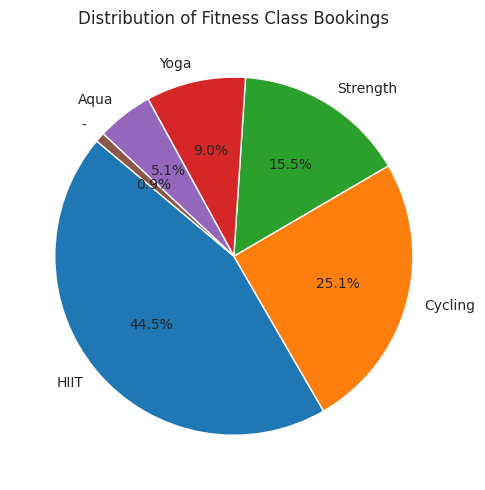

In [25]:
category_counts = df_copy['category'].value_counts()
plt.figure(figsize=(5,5))
plt.pie( category_counts, labels = category_counts.index, autopct='%1.1f%%', startangle=140 )
plt.title('Distribution of Fitness Class Bookings')
plt.tight_layout()
plt.show()

This pie chart illustrates the proportion of total bookings made across each fitness class category, highlighting HIIT as the primary driver with nearly half of all bookings (44.5%), followed by Cycling (25.1%).
Why it matters: Understanding class popularity allows management to optimize schedule slots, allocate popular instructors, and address low-demand categories to maximize facility attendance.
# Conclusions
## Question 1: What factors best predict whether a member will attend a class?
The data strongly supports that membership length (months_as_member) is the single best predictor of class attendance, exhibiting a moderate positive linear relationship ($r = 0.49$) with the attendance target. Long-standing members show significantly higher attendance rates, while member body weight displays a slight negative association ($r = -0.28$) with attendance. The data does not support the idea that booking lead time (days_before) acts as a predictive factor, as it shows virtually zero linear correlation ($r = 0.02$) with attendance.
# Question 2: Which class categories and time slots (AM vs. PM) have the highest attendance and demand?
In terms of overall demand, HIIT is the dominant category with 667 bookings (nearly 45% of all bookings), followed by Cycling (376 bookings) and Strength (233 bookings). However, when evaluating attendance efficiency, Aqua yields the highest attendance rate at 32.9% despite representing lower total volume, whereas Strength registers the lowest attendance rate at 26.6%. The data does not support substantial category-driven variation in attendance, as attendance rates across all named sports cluster closely between 26% and 33%; furthermore, the uncleaned category "-" exhibits a severe drop-off (15.4% attendance) that reflects dirty tracking rather than genuine member demand patterns.
## Question 3: Does booking significantly in advance (days_before) correlate with higher or lower attendance rates?
The data does not support the hypothesis that lead time impacts attendance behavior. After extracting numeric values from the string-formatted days_before column, the correlation coefficient between advance booking time and actual attendance is effectively negligible ($r = 0.02$). Whether a member books days in advance or reserves a spot closer to class time has no meaningful relationship with whether they ultimately show up.

# Required Techniques Checklist (15 items)
Some requirments are not covered in the task above. Hence those are covered explicitly below.

In [26]:
# Requirement 4 - Add new column with Lambda function with .apply()

df_copy['booking_lead_type'] = df_copy['days_before'].apply(
    lambda x: 'Advance' if x >= 7 else 'Short-notice'
)
# Requirement 5 - Add new column with Named function (def ...) with .apply()
                # Add column 'member_tier' to categorize membership longevity
def categorize_member_tier(months):
    if months < 6:
        return 'New'
    elif months <= 12:
        return 'Regular'
    else:
        return 'Loyal'
df_copy['member_tier'] = df_copy['months_as_member'].apply(categorize_member_tier)

print(df_copy[['days_before', 'booking_lead_type', 'months_as_member', 'member_tier']].head(10))

   days_before booking_lead_type  months_as_member member_tier
0          8.0           Advance                17       Loyal
1          2.0      Short-notice                10     Regular
2         14.0           Advance                16       Loyal
3         10.0           Advance                 5         New
4          8.0           Advance                15       Loyal
5          2.0      Short-notice                 7     Regular
6          6.0      Short-notice                11     Regular
7         10.0           Advance                 9     Regular
8         10.0           Advance                23       Loyal
9         10.0           Advance                 7     Regular


In [29]:
# Requirement 6 - NumPy operation directly (np.where)
df_copy['tenure_over_1year'] = np.where(df_copy['months_as_member'] > 12, 1, 0)

# Requirement 7 - Sort values by at least 2 columns at once
df_sorted = df_copy.sort_values( by=['category', 'months_as_member'], ascending=[False, False] )

print("Sorted DataFrame sample:")
print(df_sorted[['category', 'months_as_member', 'attended', 'tenure_over_1year']].head(10))

# Requirement 8 - Group with .groupby() and compute a SINGLE aggregate (.mean())
avg_attendance_by_category = df_copy.groupby('category')['attended'].mean()
print("\nMean Attendance Rate by Category:", avg_attendance_by_category)

Sorted DataFrame sample:
     category  months_as_member  attended  tenure_over_1year
1449     Yoga                69         1                  1
1103     Yoga                47         1                  1
1054     Yoga                44         1                  1
140      Yoga                42         1                  1
423      Yoga                41         1                  1
643      Yoga                40         1                  1
406      Yoga                39         0                  1
1299     Yoga                38         1                  1
193      Yoga                37         1                  1
111      Yoga                34         1                  1

Mean Attendance Rate by Category: category
-           0.153846
Aqua        0.328947
Cycling     0.292553
HIIT        0.319340
Strength    0.266094
Yoga        0.311111
Name: attended, dtype: float64


In [30]:

#  Requirement 15 - Use a Dictionary Comprehension for Cleaning / Standardizing
                    # Normalize inconsistent day_of_week entries (e.g., 'Wednesday', 'Mon.', 'Fri')
                    # into standardized 3-letter codes {'Wednesday': 'WED', 'Wed': 'WED', 'Mon': 'MON', ...} using a dictionary comprehension lookup
df_cleaned = df.copy()
raw_days = df_cleaned['day_of_week'].dropna().unique()
day_cleanup_map = { day: day.replace('.', '').strip()[:3].upper() for day in raw_days }

df_cleaned['day_of_week_clean'] = df_cleaned['day_of_week'].map(day_cleanup_map)

print("Standardized Day Mapping:", day_cleanup_map)

# Requirement 14 - Merge/Join a Second Lookup DataFrame
                  # Create a sensible domain lookup table containing studio room capacity
                  # and instructor type per class category, then merge it with df_cleaned

category_lookup = pd.DataFrame({
    'category': ['HIIT', 'Cycling', 'Strength', 'Yoga', 'Aqua'],
    'studio_room': ['Studio A', 'Spin Arena', 'Weight Room', 'Studio B', 'Pool Area'],
    'room_capacity': [30, 25, 20, 20, 15]
})
df_cleaned = df_cleaned.merge(category_lookup, on='category', how='left')
print("\nMerged Data Sample:")
print(df_cleaned[['booking_id', 'category', 'studio_room', 'room_capacity', 'day_of_week_clean']].head(10))

Standardized Day Mapping: {'Wed': 'WED', 'Mon': 'MON', 'Sun': 'SUN', 'Fri': 'FRI', 'Thu': 'THU', 'Wednesday': 'WED', 'Fri.': 'FRI', 'Tue': 'TUE', 'Sat': 'SAT', 'Monday': 'MON'}

Merged Data Sample:
   booking_id  category  studio_room  room_capacity day_of_week_clean
0           1  Strength  Weight Room           20.0               WED
1           2      HIIT     Studio A           30.0               MON
2           3  Strength  Weight Room           20.0               SUN
3           4   Cycling   Spin Arena           25.0               FRI
4           5      HIIT     Studio A           30.0               THU
5           6   Cycling   Spin Arena           25.0               MON
6           7      HIIT     Studio A           30.0               WED
7           8      HIIT     Studio A           30.0               FRI
8           9      HIIT     Studio A           30.0               FRI
9          10      HIIT     Studio A           30.0               FRI
